## Step 1: Import Library and classes

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## Step 2: Create a dataset with 100 Customers and 5 columns

In [3]:
np.random.seed(42)
data = {
    'CustomerID':np.arange(1,101),
    'Age':np.random.randint(18, 65, size=100),
    'Average_Spend':np.random.uniform(5,50, size=100),
    'Visits_per_Week':np.random.uniform(1,7,size=100),
    'Promotion_Interest':np.random.randint(1,11, size=100)
}

#Convert to a DataFrame
df = pd.DataFrame(data)
df.head()

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest
0,1,56,18.206968,5.266897,2
1,2,46,5.633592,5.857006,9
2,3,32,13.947908,3.091996,8
3,4,60,37.010388,1.577059,10
4,5,25,40.557899,6.643140,7


In [4]:
#Here, we don't have output/target/dependent feature column, hence it belongs to unsupervised learning problem

## Step 3: Apply KMeans clustering to segment customers into 3 groups
#### Find cluster number

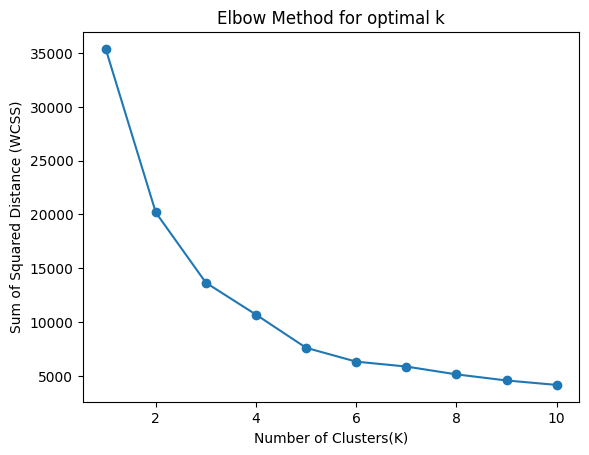

In [11]:
# n = 3
#Lets find the Kth clusters need for this problem statement using Elbow Method
x = df[['Age','Average_Spend','Visits_per_Week','Promotion_Interest']]
# x
#wcss => within clusture sum of square distance
wcss = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel("Sum of Squared Distance (WCSS)")
plt.title("Elbow Method for optimal k")
plt.show()

In [12]:
#lets create a new dataframe with features and clusters associated with it
features = df[['Age','Average_Spend','Visits_per_Week','Promotion_Interest']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)
df

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest,Cluster
0,1,56,18.206968,5.266897,2,2
1,2,46,5.633592,5.857006,9,2
2,3,32,13.947908,3.091996,8,2
3,4,60,37.010388,1.577059,10,0
4,5,25,40.557899,6.643140,7,1
...,...,...,...,...,...,...
95,96,24,27.868945,1.819728,10,1
96,97,26,36.311576,5.253466,10,1
97,98,41,43.626146,4.316920,3,0
98,99,18,19.668151,2.779061,10,1


In [13]:
#Here, we have 3 clusters: 0, 1 ,2
'''
0 => Daily Customers
1 => Promotion Customers
2 => Weekend Customers
'''

'\n0 => Daily Customers\n1 => Promotion Customers\n2 => Weekend Customers\n'

In [14]:
cluster_names = {0: 'Daily', 1:'Promotion',2:'Weekend'}
df['Cluster_Group'] = df['Cluster'].map(cluster_names)
df.head()

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest,Cluster,Cluster_Group
0,1,56,18.206968,5.266897,2,2,Weekend
1,2,46,5.633592,5.857006,9,2,Weekend
2,3,32,13.947908,3.091996,8,2,Weekend
3,4,60,37.010388,1.577059,10,0,Daily
4,5,25,40.557899,6.643140,7,1,Promotion


## Step 4: Visualize the clusters using Age and Average Spend (2D Plot)

<function matplotlib.pyplot.show(close=None, block=None)>

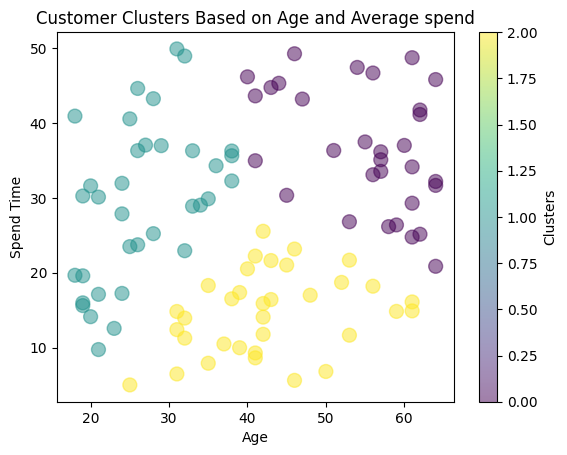

In [15]:
plt.scatter(df['Age'],df['Average_Spend'], c=df['Cluster'], cmap='viridis', marker='o', s=100, alpha=0.5)
plt.title("Customer Clusters Based on Age and Average spend")
plt.xlabel("Age")
plt.ylabel("Spend Time")
plt.colorbar(label='Clusters')
plt.show

## Step 5: Evaluate the clustering performance

In [17]:
#Using silhouette score/measure
print(silhouette_score(features, df['Cluster']))

0.36846369703368004


## Step 5.1: Save KMeans For Future Inference

In [18]:
import pickle
pickle.dump(kmeans, open("customer_kmeans.pkl","wb"))

In [19]:
kmeans = pickle.load(open("customer_kmeans.pkl", "rb"))

## Step 6: Predic the cluster of a new customer

In [24]:
def clustering(age,avg_spend,visit_per_week,promotion_interest):
    new_customer = np.array([[age,avg_spend,visit_per_week,promotion_interest]])
    predicted_cluster = kmeans.predict(new_customer)

    if predicted_cluster[0] == 0:
        return "Daily"
    elif predicted_cluster[0] == 1:
        return "Promotion"
    else:
        return "Weekend"

In [25]:
#new customer
age = 41
avg_spend = 30
visit_per_week = 4
promotion_interest = 7

clustering(age,avg_spend,visit_per_week,promotion_interest)

C:\Users\Laptop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


'Promotion'

In [26]:
#new customer 2
age = 40
avg_spend = 10
visit_per_week = 1
promotion_interest = 0

clustering(age,avg_spend,visit_per_week,promotion_interest)

C:\Users\Laptop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


'Weekend'